In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from network import NetCNN1D, NetCNN2D_CSP


from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd



config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = ['CLeft', 'CRight']
config.session_type = 'S3'


config.t_start = 0 
config.t_end = 3.0

window_size = 2.0
stride = 0.1

stride = int(stride * 250)
window_size = int(window_size * 250)


config.n_csp_components = 3

# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']


config.start = int(config.t_start * 250)
config.t_end = int(config.t_end * 250)

In [2]:
model = NetCNN1D(2)#NetCNN2D_CSP(2)
model.build((32, 3, 750, 1))
model.summary()

ValueError: Exception encountered when calling layer 'sequential' (type Sequential).

Input 0 of layer "global_average_pooling1d" is incompatible with the layer: expected ndim=3, found ndim=4. Full shape received: (32, 3, 21, 32)

Call arguments received by layer 'sequential' (type Sequential):
  • inputs=tf.Tensor(shape=(32, 3, 750, 1), dtype=float32)
  • training=None
  • mask=None

In [3]:
X, y = dataset_NewEEG.session_dataset(config ,'I09')

In [4]:
print(X.shape)

(8, 13, 750)


c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


(6, 13, 750)
(2, 13, 750)
Epoch 1/300

3/3 [==============================] - 3s 231ms/step - loss: 0.7436 - acc: 0.3636 - val_loss: 0.6941 - val_acc: 0.5000
Epoch 2/300
3/3 [==============================] - 0s 32ms/step - loss: 0.6999 - acc: 0.5455 - val_loss: 0.6938 - val_acc: 0.2727
Epoch 3/300
3/3 [==============================] - 0s 41ms/step - loss: 0.6974 - acc: 0.4697 - val_loss: 0.6935 - val_acc: 0.5000
Epoch 4/300
3/3 [==============================] - 0s 37ms/step - loss: 0.6835 - acc: 0.5758 - val_loss: 0.6931 - val_acc: 0.5000
Epoch 5/300
3/3 [==============================] - 0s 32ms/step - loss: 0.6723 - acc: 0.6515 - val_loss: 0.6929 - val_acc: 0.5000
Epoch 6/300
3/3 [==============================] - 0s 33ms/step - loss: 0.6828 - acc: 0.5303 - val_loss: 0.6925 - val_acc: 0.5000
Epoch 7/300
3/3 [==============================] - 0s 37ms/step - loss: 0.6712 - acc: 0.5758 - val_loss: 0.6921 - val_acc: 0.5000
Epoch 8/300
3/3 [==============================] - 0s 34ms/ste

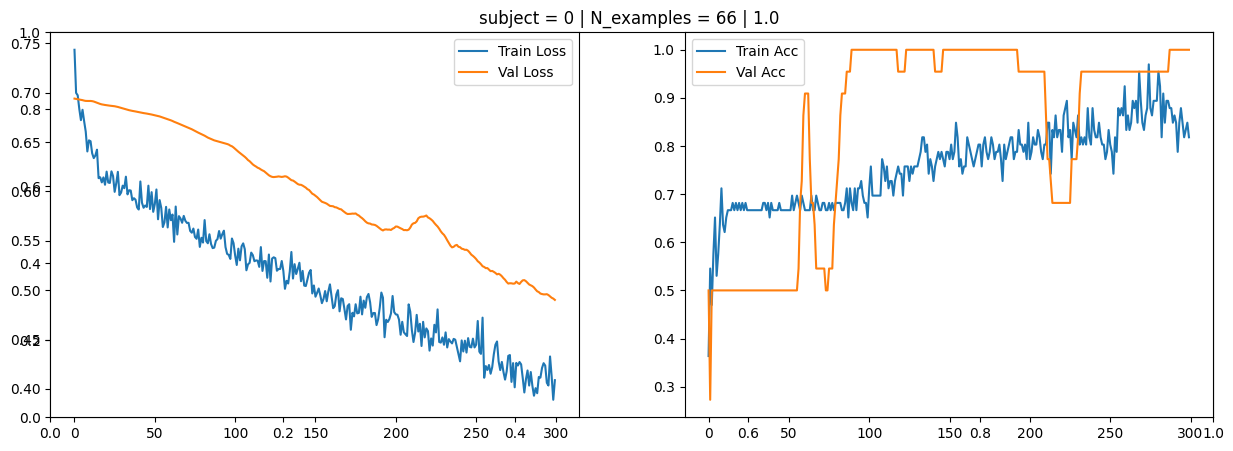

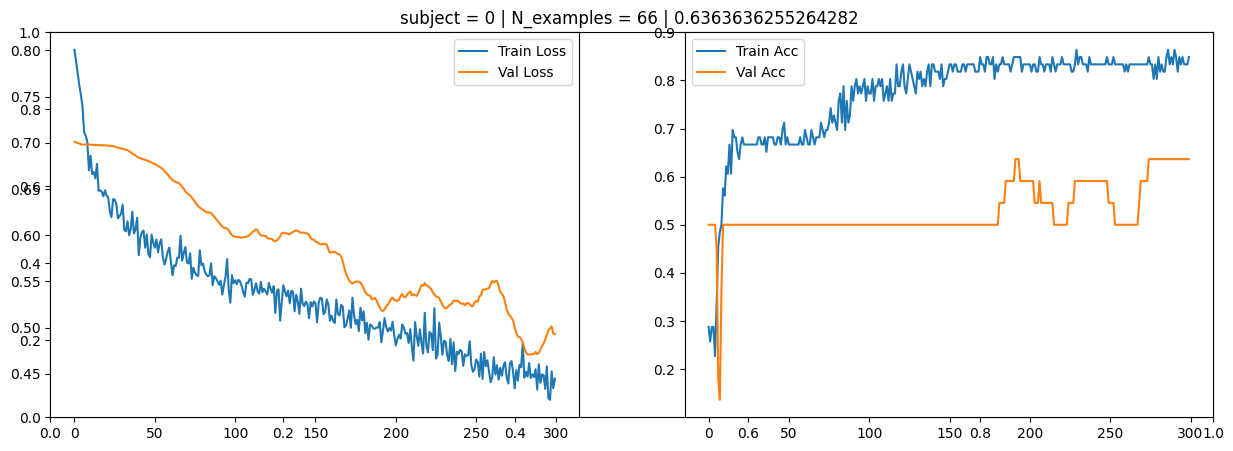

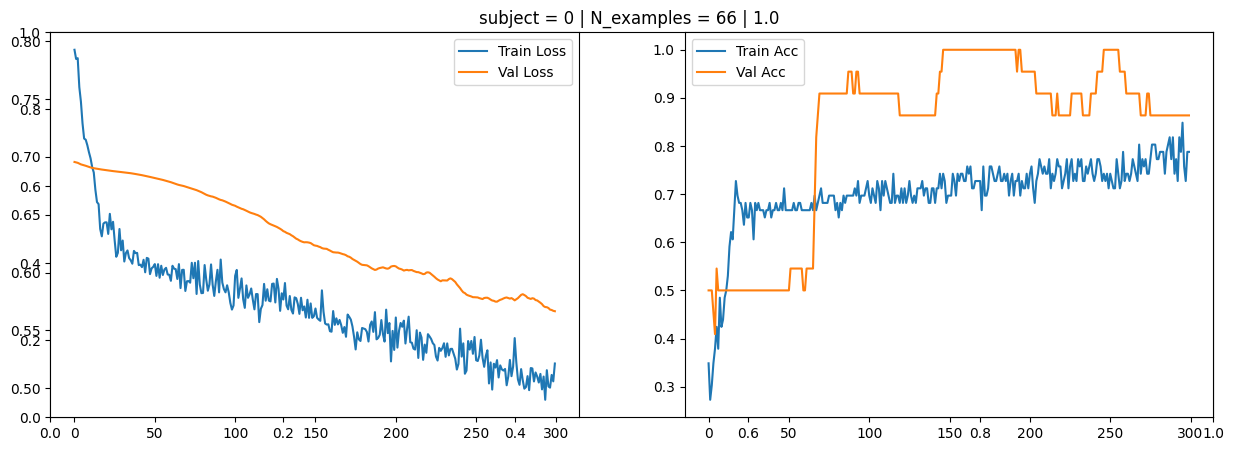

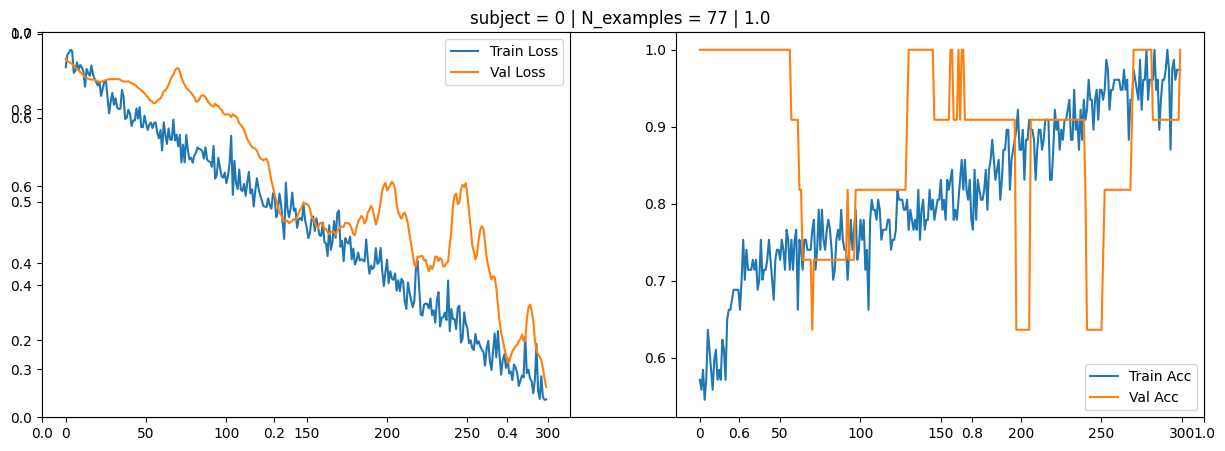

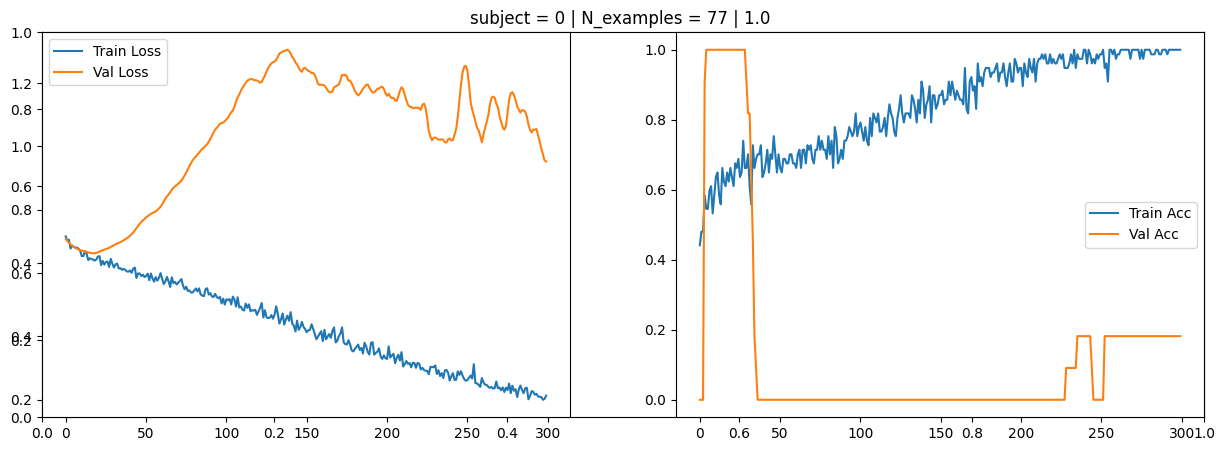

In [5]:
crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in crossValidation_KF.split(X,y):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    print(X_train.shape)
    print(X_valid.shape)


    X_train_sliced, Y_train_sliced = [], []
    X_valid_sliced, Y_valid_sliced = [], []

    #print(config.t_start)
    #print(config.t_end)
    #print(window_size)
    #print(stride)

    for i in range(len(X_train)):
        for start in range(config.t_start, config.t_end - window_size + 1, stride):
                X_train_sliced.append(X_train[i][:, start:start+window_size][np.newaxis])
                Y_train_sliced.append(Y_train[i])
    



    X_train_sliced, Y_train_sliced = np.concatenate(X_train_sliced), np.array(Y_train_sliced)

    shuffle_indices = np.random.permutation(len(Y_train_sliced))
    X_train_sliced = X_train_sliced[shuffle_indices]
    Y_train_sliced = Y_train_sliced[shuffle_indices]



    for i in range(len(X_valid)):
        for start in range(config.t_start, config.t_end - window_size + 1, stride):
                X_valid_sliced.append(X_valid[i][:, start:start+window_size][np.newaxis])
                Y_valid_sliced.append(Y_valid[i])
    



    X_valid_sliced, Y_valid_sliced = np.concatenate(X_valid_sliced), np.array(Y_valid_sliced)

    shuffle_indices = np.random.permutation(len(Y_valid_sliced))
    X_valid_sliced = X_valid_sliced[shuffle_indices]
    Y_valid_sliced = Y_valid_sliced[shuffle_indices]




    



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train_sliced = csp.fit_transform(X_train_sliced, Y_train_sliced)
    X_valid_sliced = csp.transform(X_valid_sliced)


    X_train_sliced = np.expand_dims(X_train_sliced, 3)
    X_valid_sliced = np.expand_dims(X_valid_sliced, 3)

    #X_train_sliced = X_train_sliced.transpose(0, 2, 1)
    #X_valid_sliced = X_valid_sliced.transpose(0, 2, 1)

    Y_train_sliced = tf.keras.utils.to_categorical(Y_train_sliced, num_classes = 2)
    Y_valid_sliced = tf.keras.utils.to_categorical(Y_valid_sliced, num_classes = 2)



    model = NetCNN2D_CSP(2) #NetCNN1D() 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
            optimizer=keras.optimizers.Adam(learning_rate=1.5e-4, weight_decay = 1e-5), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    sys.stdout.close()
    sys.stdout = old_stdout

    history = model.fit(X_train_sliced, Y_train_sliced, validation_data=(X_valid_sliced, Y_valid_sliced), epochs=300, batch_size=32, verbose=1)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train_sliced.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    



print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")

In [ ]:
{}

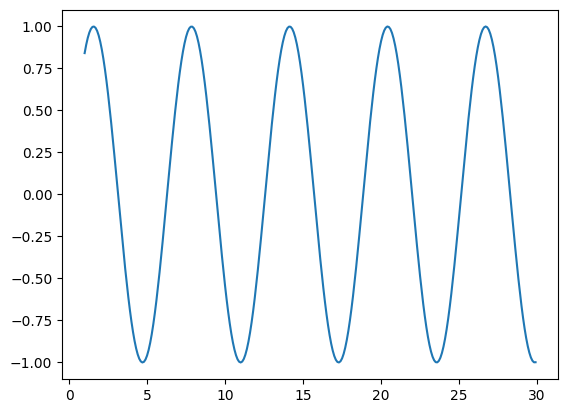

In [11]:
import matplotlib.pyplot as plt

x = np.arange(1,30, step=0.1)
y = np.sin(x)

plt.plot(x, y)
